# 02 — Parameter Sensitivity Analysis

Evaluate how `min_support`, `min_cooccurrence`, and `min_lift` affect the graph size and data coverage.

**Central question:** how strict does each threshold need to be to cover X% of the data while controlling graph noise?

## 0. Setup

In [ ]:
import sys, os
sys.path.insert(0, os.path.join(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from itertools import product as iterproduct

from src.preprocessing import load_transactions, clean_transactions, split_by_day
from src.graph_builder import build_cooccurrence, compute_lift

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (10, 4)})

## 1. Load raw data

In [ ]:
RAW_TRANSACTIONS = "../data/raw/transaction_data.parquet"
RAW_PRODUCTS     = "../data/raw/product.parquet"

df_raw = load_transactions(RAW_TRANSACTIONS, product_parquet_path=RAW_PRODUCTS)
df_raw = df_raw.drop_duplicates(subset=["basket_id", "product_id"])

total_rows    = len(df_raw)
total_baskets = df_raw["basket_id"].nunique()
total_products = df_raw["product_id"].nunique()

print(f"Rows:     {total_rows:,}")
print(f"Baskets:  {total_baskets:,}")
print(f"Products: {total_products:,}")

## 2. `min_support` — product frequency filter

`min_support` removes products that appear in fewer than N baskets.
It controls the **node set** of the graph before any edge is computed.

In [ ]:
# Support = number of distinct baskets each product appears in
product_support = df_raw.groupby("product_id")["basket_id"].nunique().sort_values(ascending=False)

print(f"Median support: {product_support.median():.0f} baskets")
print(f"Mean support:   {product_support.mean():.1f} baskets")
print(f"Products with support == 1: {(product_support == 1).sum():,}")
product_support.describe(percentiles=[.5, .75, .9, .95, .99])

Median support: 3 baskets
Mean support:   28.1 baskets
Products with support == 1: 33,614


count    92339.000000
mean        28.110896
std        191.960855
min          1.000000
50%          3.000000
75%         13.000000
90%         57.000000
95%        115.000000
99%        365.620000
max      29778.000000
Name: basket_id, dtype: float64

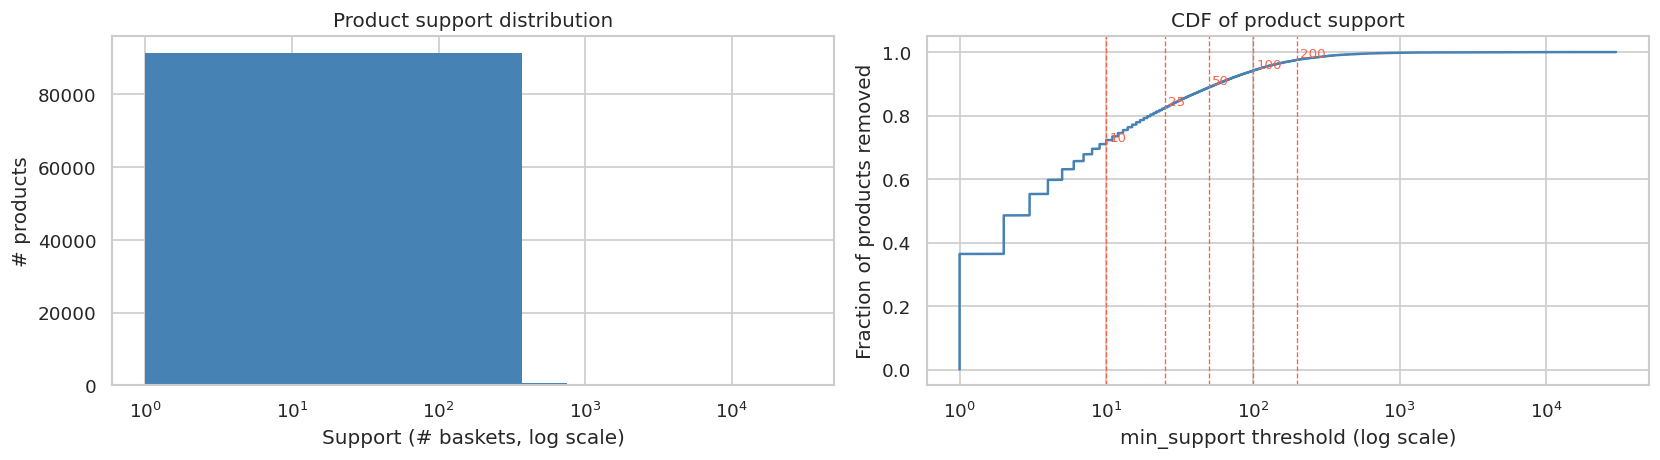

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribution (log-scale x)
axes[0].hist(product_support.values, bins=80, color="steelblue", edgecolor="none")
axes[0].set_xscale("log")
axes[0].set_xlabel("Support (# baskets, log scale)")
axes[0].set_ylabel("# products")
axes[0].set_title("Product support distribution")

# CDF
sorted_support = np.sort(product_support.values)
cdf = np.arange(1, len(sorted_support) + 1) / len(sorted_support)
axes[1].plot(sorted_support, cdf, color="steelblue")
axes[1].set_xscale("log")
axes[1].set_xlabel("min_support threshold (log scale)")
axes[1].set_ylabel("Fraction of products removed")
axes[1].set_title("CDF of product support")
for thresh in [10, 25, 50, 100, 200]:
    frac = (product_support < thresh).mean()
    axes[1].axvline(thresh, color="tomato", lw=0.8, ls="--")
    axes[1].text(thresh * 1.05, frac + 0.01, f"{thresh}", fontsize=8, color="tomato")

plt.tight_layout()
plt.show()

In [ ]:
# How much of the data (rows / transactions) is retained at each min_support?
thresholds = [1, 5, 10, 25, 50, 100, 150, 200, 300, 500]
rows = []
for t in thresholds:
    kept_products = product_support[product_support >= t].index
    kept_df = df_raw[df_raw["product_id"].isin(kept_products)]
    rows.append({
        "min_support": t,
        "n_products": len(kept_products),
        "pct_products": 100 * len(kept_products) / total_products,
        "n_rows": len(kept_df),
        "pct_rows": 100 * len(kept_df) / total_rows,
        "n_baskets_touched": kept_df["basket_id"].nunique(),
        "pct_baskets": 100 * kept_df["basket_id"].nunique() / total_baskets,
    })

support_df = pd.DataFrame(rows)
support_df.set_index("min_support").style.format({
    "pct_products": "{:.1f}%",
    "pct_rows": "{:.1f}%",
    "pct_baskets": "{:.1f}%",
    "n_products": "{:,}",
    "n_rows": "{:,}",
    "n_baskets_touched": "{:,}",
})

,n_products,pct_products,n_rows,pct_rows,n_baskets_touched,pct_baskets
min_support,,,,,,
1,"92,339",100.0%,"2,595,732",100.0%,"276,484",100.0%
5,"37,177",40.3%,"2,504,571",96.5%,"272,920",98.7%
10,"26,780",29.0%,"2,436,014",93.8%,"269,974",97.6%
25,"16,497",17.9%,"2,276,589",87.7%,"264,027",95.5%
50,"10,370",11.2%,"2,061,552",79.4%,"256,396",92.7%
100,"5,480",5.9%,"1,717,253",66.2%,"245,923",88.9%
150,"3,351",3.6%,"1,460,051",56.2%,"237,922",86.1%
200,"2,273",2.5%,"1,274,030",49.1%,"230,827",83.5%
300,"1,325",1.4%,"1,044,213",40.2%,"221,012",79.9%


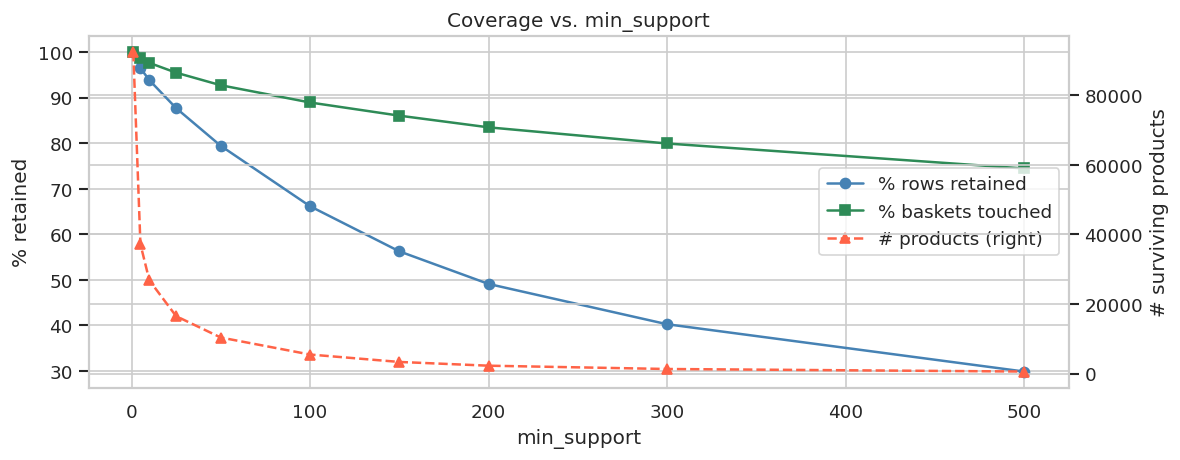

In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()

ax1.plot(support_df["min_support"], support_df["pct_rows"], marker="o", color="steelblue", label="% rows retained")
ax1.plot(support_df["min_support"], support_df["pct_baskets"], marker="s", color="seagreen", label="% baskets touched")
ax2.plot(support_df["min_support"], support_df["n_products"], marker="^", color="tomato", ls="--", label="# products")

ax1.set_xlabel("min_support")
ax1.set_ylabel("% retained")
ax2.set_ylabel("# surviving products")
ax1.set_title("Coverage vs. min_support")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right")
plt.tight_layout()
plt.show()

## 3. `min_cooccurrence` — edge density filter

`min_cooccurrence` prunes pairs that appear together in fewer than N baskets.
It directly controls how many candidate edges exist before the lift filter.

In [ ]:
# Use a fixed min_support to build a representative product set
FIXED_MIN_SUPPORT = 50  # adjust if needed
TRAIN_FRACTION = 0.8

df_clean, product_index, product_meta = clean_transactions(df_raw, min_support=FIXED_MIN_SUPPORT)
n_products = len(product_index)
print(f"min_support={FIXED_MIN_SUPPORT}: {n_products:,} products, {len(df_clean):,} rows")

train_baskets, _, _cutoff = split_by_day(df_clean, train_fraction=TRAIN_FRACTION)
print(f"Train baskets: {len(train_baskets):,}")

cooc = build_cooccurrence(train_baskets, n_products)
print(f"Co-occurrence nonzeros (raw): {cooc.C.nnz:,}")

In [ ]:
import scipy.sparse as sp

C_coo = cooc.C.tocoo()
# Only upper triangle to avoid double-counting symmetric pairs
upper_mask = C_coo.row < C_coo.col
cooc_counts = C_coo.data[upper_mask]
total_pairs = len(cooc_counts)
total_weight = cooc_counts.sum()

print(f"Unique pairs: {total_pairs:,}")
print(f"Total co-occurrence weight: {total_weight:,}")
print(f"Median co-occurrence: {np.median(cooc_counts):.0f}")
print(f"Pairs with cooccurrence == 1: {(cooc_counts == 1).sum():,} ({100*(cooc_counts==1).mean():.1f}%)")

Unique pairs: 8,484,975
Total co-occurrence weight: 16,883,521
Median co-occurrence: 1
Pairs with cooccurrence == 1: 5,848,651 (68.9%)


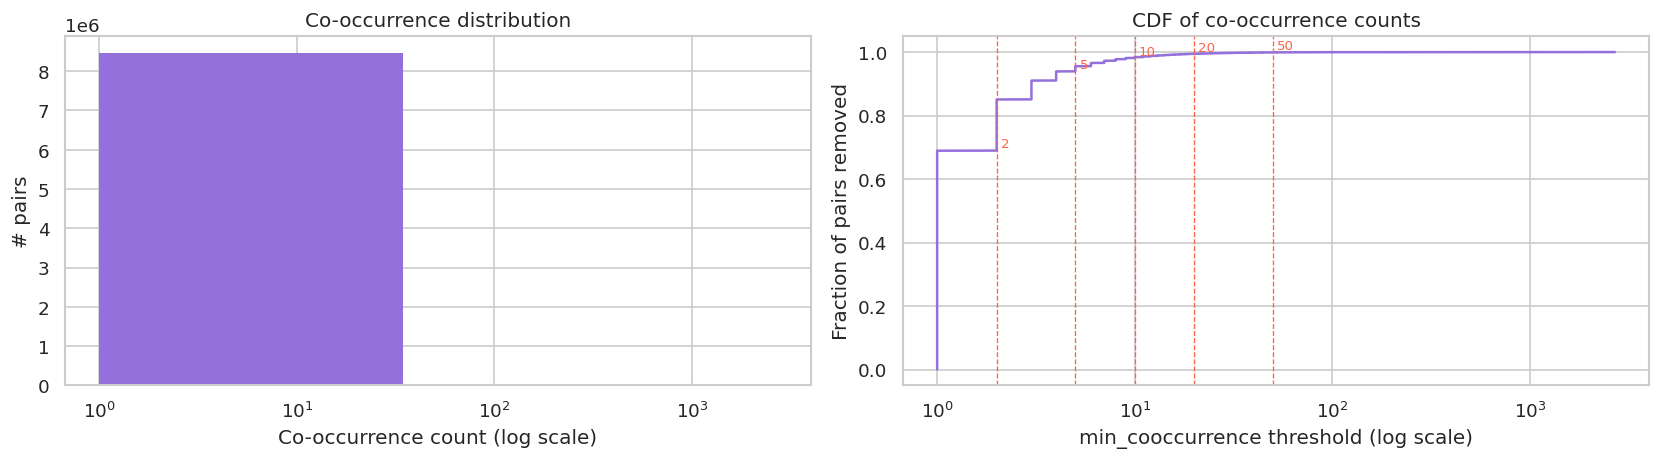

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(cooc_counts, bins=80, color="mediumpurple", edgecolor="none")
axes[0].set_xscale("log")
axes[0].set_xlabel("Co-occurrence count (log scale)")
axes[0].set_ylabel("# pairs")
axes[0].set_title("Co-occurrence distribution")

sorted_cooc = np.sort(cooc_counts)
cdf_cooc = np.arange(1, len(sorted_cooc) + 1) / len(sorted_cooc)
axes[1].plot(sorted_cooc, cdf_cooc, color="mediumpurple")
axes[1].set_xscale("log")
axes[1].set_xlabel("min_cooccurrence threshold (log scale)")
axes[1].set_ylabel("Fraction of pairs removed")
axes[1].set_title("CDF of co-occurrence counts")
for thresh in [2, 5, 10, 20, 50]:
    frac = (cooc_counts < thresh).mean()
    axes[1].axvline(thresh, color="tomato", lw=0.8, ls="--")
    axes[1].text(thresh * 1.05, frac + 0.01, f"{thresh}", fontsize=8, color="tomato")

plt.tight_layout()
plt.show()

In [ ]:
cooc_thresholds = [1, 2, 3, 5, 10, 15, 20, 30, 50]
cooc_rows = []
for t in cooc_thresholds:
    kept = cooc_counts >= t
    cooc_rows.append({
        "min_cooccurrence": t,
        "n_pairs": kept.sum(),
        "pct_pairs": 100 * kept.mean(),
        "pct_weight": 100 * cooc_counts[kept].sum() / total_weight,
    })

cooc_df = pd.DataFrame(cooc_rows)
cooc_df.set_index("min_cooccurrence").style.format({
    "pct_pairs": "{:.1f}%",
    "pct_weight": "{:.1f}%",
    "n_pairs": "{:,}",
})

,n_pairs,pct_pairs,pct_weight
min_cooccurrence,,,
1,"8,484,975",100.0%,100.0%
2,"2,636,324",31.1%,65.4%
3,"1,266,786",14.9%,49.1%
5,"517,436",6.1%,34.4%
10,"159,545",1.9%,21.1%
15,"80,814",1.0%,15.7%
20,"49,557",0.6%,12.6%
30,"24,543",0.3%,9.1%
50,"9,895",0.1%,5.9%


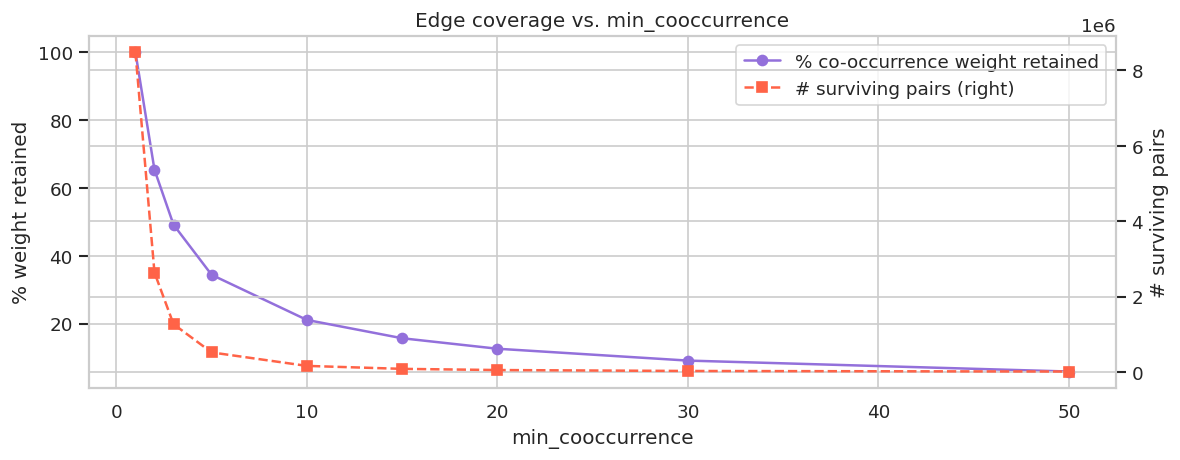

In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()

ax1.plot(cooc_df["min_cooccurrence"], cooc_df["pct_weight"], marker="o", color="mediumpurple", label="% co-occurrence weight retained")
ax2.plot(cooc_df["min_cooccurrence"], cooc_df["n_pairs"], marker="s", color="tomato", ls="--", label="# surviving pairs")

ax1.set_xlabel("min_cooccurrence")
ax1.set_ylabel("% weight retained")
ax2.set_ylabel("# surviving pairs")
ax1.set_title("Edge coverage vs. min_cooccurrence")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)
plt.tight_layout()
plt.show()

## 4. `min_lift` — association strength filter

`min_lift` prunes edges where the co-occurrence is not stronger than expected by chance.
Values > 1 mean the pair appears together more often than random.

In [ ]:
# Compute lift with no cooccurrence filter to see the full distribution
lift_mat = compute_lift(cooc, min_lift=0.0, min_cooccurrence=1)
lift_coo = lift_mat.tocoo()
upper_lift_mask = lift_coo.row < lift_coo.col
lift_vals = lift_coo.data[upper_lift_mask]

print(f"Total pairs with lift computed: {len(lift_vals):,}")
print(f"Pairs with lift > 1.0: {(lift_vals > 1.0).sum():,} ({100*(lift_vals>1.0).mean():.1f}%)")
print(f"Median lift: {np.median(lift_vals):.3f}")
print(f"90th percentile: {np.percentile(lift_vals, 90):.3f}")

Total pairs with lift computed: 8,484,975
Pairs with lift > 1.0: 8,356,043 (98.5%)
Median lift: 10.074
90th percentile: 41.675


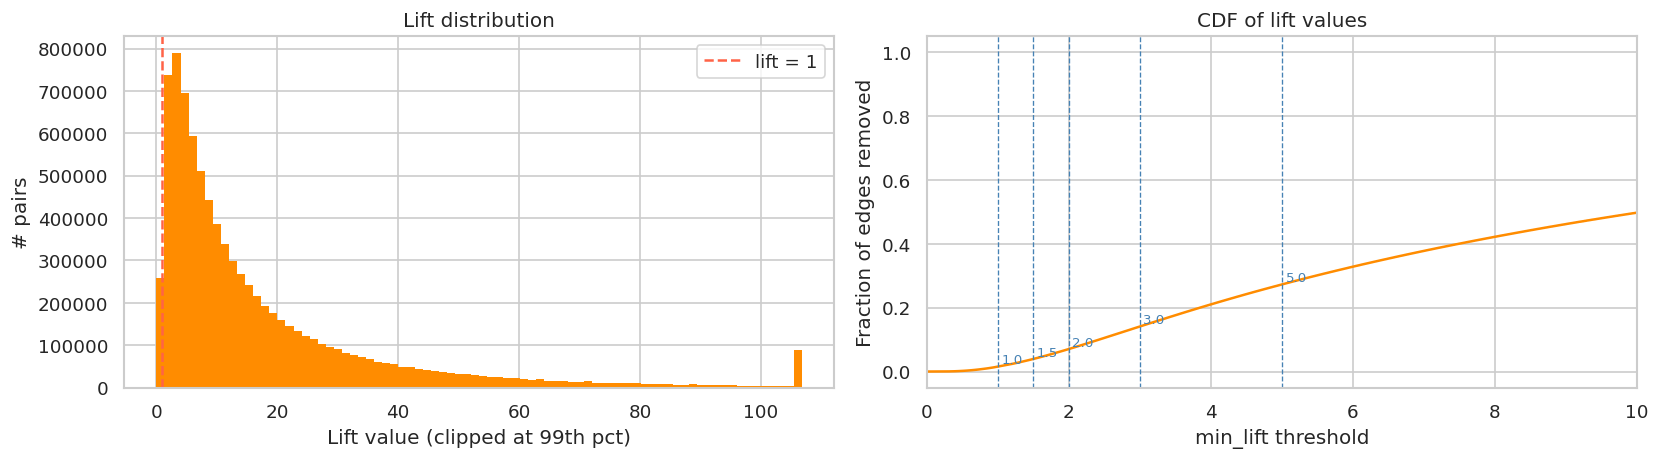

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

clip_lift = np.clip(lift_vals, 0, np.percentile(lift_vals, 99))  # clip outliers for viz
axes[0].hist(clip_lift, bins=80, color="darkorange", edgecolor="none")
axes[0].axvline(1.0, color="tomato", lw=1.5, ls="--", label="lift = 1")
axes[0].set_xlabel("Lift value (clipped at 99th pct)")
axes[0].set_ylabel("# pairs")
axes[0].set_title("Lift distribution")
axes[0].legend()

sorted_lift = np.sort(lift_vals)
# For the CDF: fraction of pairs REMOVED as we increase min_lift
cdf_lift = np.arange(1, len(sorted_lift) + 1) / len(sorted_lift)
axes[1].plot(sorted_lift, cdf_lift, color="darkorange")
axes[1].set_xlabel("min_lift threshold")
axes[1].set_ylabel("Fraction of edges removed")
axes[1].set_title("CDF of lift values")
axes[1].set_xlim(0, min(10, sorted_lift.max()))
for thresh in [1.0, 1.5, 2.0, 3.0, 5.0]:
    frac = (lift_vals < thresh).mean()
    if thresh <= sorted_lift.max():
        axes[1].axvline(thresh, color="steelblue", lw=0.8, ls="--")
        axes[1].text(thresh + 0.05, frac + 0.01, f"{thresh}", fontsize=8, color="steelblue")

plt.tight_layout()
plt.show()

In [ ]:
lift_thresholds = [0.5, 1.0, 1.2, 1.5, 2.0, 3.0, 5.0]
lift_rows = []
for t in lift_thresholds:
    kept = lift_vals > t
    lift_rows.append({
        "min_lift": t,
        "n_edges": kept.sum(),
        "pct_edges": 100 * kept.mean(),
    })

lift_df = pd.DataFrame(lift_rows)
lift_df.set_index("min_lift").style.format({
    "pct_edges": "{:.1f}%",
    "n_edges": "{:,}",
})

,n_edges,pct_edges
min_lift,,
0.500000,"8,467,971",99.8%
1.000000,"8,356,043",98.5%
1.200000,"8,282,996",97.6%
1.500000,"8,150,963",96.1%
2.000000,"7,886,979",93.0%
3.000000,"7,288,240",85.9%
5.000000,"6,171,030",72.7%


## 5. Joint sensitivity: graph size as a function of all parameters

Sweep `(min_support, min_cooccurrence)` with a fixed `min_lift`, then visualize the resulting graph shape.

In [ ]:
FIXED_MIN_LIFT   = 1.0
SUPPORT_GRID     = [10, 25, 50, 100, 200]
COOC_GRID        = [1, 2, 5, 10, 20]

grid_rows = []

for ms in SUPPORT_GRID:
    df_c, pidx, pmeta = clean_transactions(df_raw, min_support=ms)
    n_prod = len(pidx)
    tr_baskets, _, _cutoff = split_by_day(df_c, train_fraction=TRAIN_FRACTION)
    cooc_g = build_cooccurrence(tr_baskets, n_prod)

    for mc in COOC_GRID:
        lm = compute_lift(cooc_g, min_lift=FIXED_MIN_LIFT, min_cooccurrence=mc)
        n_edges = lm.nnz  # directed, symmetric
        # Count nodes that have at least one edge
        lm_csr = lm.tocsr()
        active_nodes = (np.diff(lm_csr.indptr) > 0).sum()
        grid_rows.append({
            "min_support": ms,
            "min_cooccurrence": mc,
            "n_products_clean": n_prod,
            "n_active_nodes": active_nodes,
            "n_edges_directed": n_edges,
        })
        print(f"  ms={ms:4d} mc={mc:3d} → nodes={active_nodes:,} edges={n_edges:,}")

grid_df = pd.DataFrame(grid_rows)
grid_df

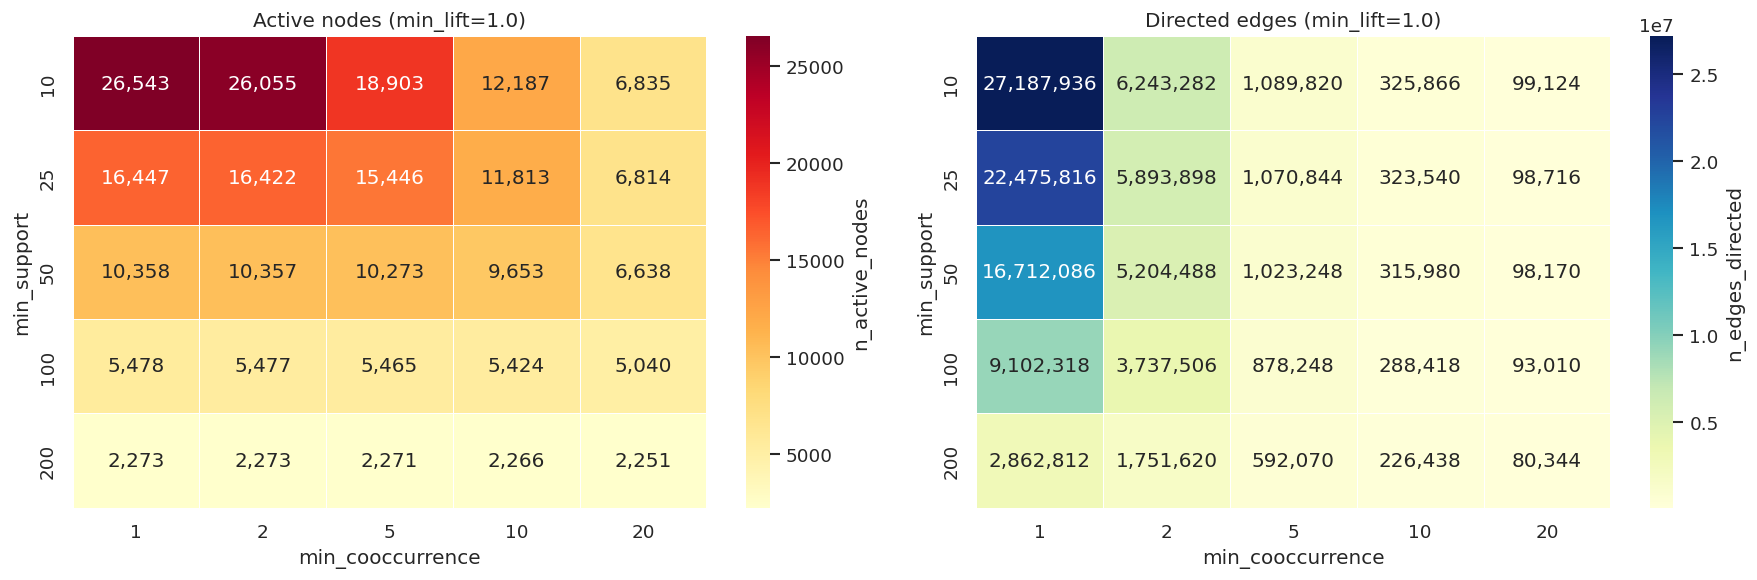

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for metric, ax, title, cmap in [
    ("n_active_nodes", axes[0], "Active nodes", "YlOrRd"),
    ("n_edges_directed", axes[1], "Directed edges", "YlGnBu"),
]:
    pivot = grid_df.pivot(index="min_support", columns="min_cooccurrence", values=metric)
    sns.heatmap(
        pivot, ax=ax, cmap=cmap, annot=True, fmt=",",
        linewidths=0.5, cbar_kws={"label": metric}
    )
    ax.set_title(f"{title} (min_lift={FIXED_MIN_LIFT})")
    ax.set_xlabel("min_cooccurrence")
    ax.set_ylabel("min_support")

plt.tight_layout()
plt.show()